In [1]:
import sys
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.models import *
from src.evaluation import print_metrics, plot_confusion, calculate_auc

In [2]:
# Load the pre-processed data from the previous step
processed_dir = Path("../data/processed")

X_train = pd.read_csv(processed_dir / "X_train.csv")
X_test = pd.read_csv(processed_dir / "X_test.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv")["label"]
y_test = pd.read_csv(processed_dir / "y_test.csv")["label"]

print(f"Loaded X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Loaded X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Loaded X_train shape: (107842, 20), y_train shape: (107842,)
Loaded X_test shape: (25195, 20), y_test shape: (25195,)


Training Random Forest Classifier...
Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     13422
           1       1.00      0.99      0.99     11773

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195

Random Forest AUC Score: 0.9998


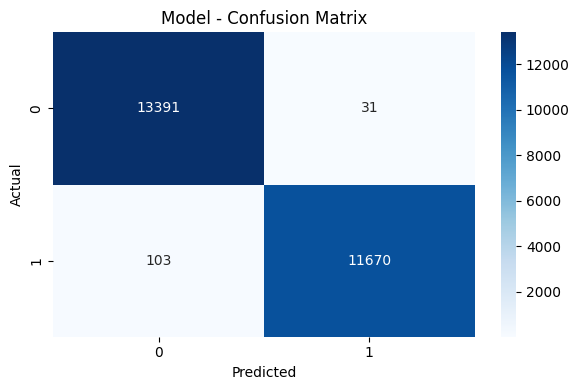

In [3]:
print("Training Random Forest Classifier...")
rf_model = train_random_forest(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
print_metrics(y_test, y_pred_rf)

# Calculate AUC
auc_rf = calculate_auc(rf_model, X_test, y_test)
print(f"Random Forest AUC Score: {auc_rf:.4f}")

plot_confusion(y_test, y_pred_rf)

Training XGBoost Classifier...


/home/samad/DS_project/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:22:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

XGBoost AUC Score: 1.0000


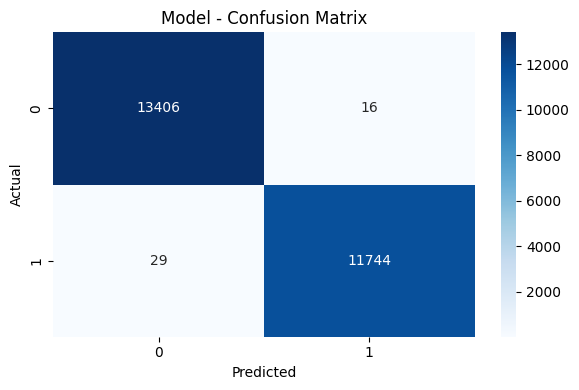

In [4]:
print("Training XGBoost Classifier...")
xgb_model = train_xgboost(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print_metrics(y_test, y_pred_xgb)

# Calculate AUC
auc_xgb = calculate_auc(xgb_model, X_test, y_test)
print(f"XGBoost AUC Score: {auc_xgb:.4f}")

plot_confusion(y_test, y_pred_xgb)